Uses the satellite TLE's and the telescope beam model, and calculates the satellites' beam response.

### 1. Initialization

Making the necessary imports.

In [3]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [4]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.tle_mapping as tle
import satellite_RFI.src.beam_model as bm
import random
import sys
sys.path.insert(0, './initialization/')
from imports import *
import parameters as pm
from skyfield.api import load
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter
from matplotlib.collections import LineCollection


### 2. Downloading TLEs and formatting correctly

#### A. Steps to download TLEs for the present day

We begin by downloading today's TLEs and saving them in the specified path. The steps for renaming the satellite names in the files were also performed for the observation TLEs once, with a slightly modified function.

In [36]:
# downloading TLEs from celestrak for the present date
path_folder = pm.folder + 'TLE/'
path = tle.download_TLEs(path_folder,verbose=True)


Writing over existing folder

In [37]:
# editing files
tle.clean_satnames(path,verbose=True)
tle.extract_QIs(path,verbose=True)


Found qzs satellites: QZS-2-(MICHIBIKI-2),QZS-3-(MICHIBIKI-3),QZS-4-(MICHIBIKI-4),QZS-1R-(MICHIBIKI-1R),QZS-6-(MICHIBIKI-6),
Found irnss satellites: IRNSS-1A,IRNSS-1B,IRNSS-1C,IRNSS-1E,IRNSS-1F,IRNSS-1G,IRNSS-1I,NVS-01-(IRNSS-1J),
Removing QZS and BEIDOU satellites from SBAS...


#### B. Extracting satellite names for satellite catalog

Celestrak changes naming conventions throughout time; as such, it's better to just employ the naming conventions that it used at the time of the observation, and just extract those names based on NORAD ID to the satellite catalog.

In [53]:
# getting catalog
satellites = pd.read_csv(pm.folder + "satellites.csv")
satellites.set_index("NORAD ID", inplace=True)
satellites.drop(columns=["Brandon Name"], inplace=True)
satellites.insert(0, f"Name {pm.block}", "")

# getting info from TLEs
cons = ["gps-ops","glo-ops","galileo","beidou","irnss","qzs","sbas"]
for con in cons:
    data = load.tle_file(path_TLEs + con + ".txt")
    for sat in data:  satellites.loc[sat.model.satnum,f"Name {pm.block}"] = sat.name


In [55]:
# saving catalog
satellites.to_csv(pm.folder + "satellites.csv", index=True)


### 3. Determining angular positions

#### A. Creating object

The calculations of the satellites' angular positions in the sky will be all calculated and saved within the `SatBeamCalculator` object, defined in *tle_mapping.py* (previously in *check_satellite.py*). I'm experimenting and will try to change the indexing from the satellite names (requires precise formatting, names change throughout time) to NORAD IDs (immutable, easy to index).

Comparing with the previous angular maps, we've managed to get rid of all satellites that had weird maps and had been incorrectly kept previously.

In [5]:
# getting the date from the block
block, date = tle.get_date(unix=pm.block, verbose=True)
path_TLEs = "simulation_data/TLE/2019_02_21_tle/"

# initializing the satbeam calculator
tsc = tle.SatBeamCalculator(
    path_TLEs = path_TLEs, 
    t_start = pm.block + pm.nd_s0[0], 
    times = pm.nd_s0, 
    location = [pm.TL_latitude, pm.TL_longitude], 
    pointings = np.array(pm.nd_s0_coords).T, 
    max_angle = 100, 
    verbose = True
)


Date of observation: 2019-02-25 02:40:11
File name: 1551055211
Extracting TLEs...
Setting time and location...
Getting coordinates and angular separations...
Number of satellites: 14 (gps-ops), 11 (glo-ops), 11 (galileo), 12 (beidou), 5 (irnss), 7 (sbas), 

#### B. Checking some plots

From this object we can already see that BEIDOU 3 M1 that is selected is 43001, and that indeed only one of the satellites appears (the other wasn't written over).

We can already compare some properties with previous results; for example, we had several weird smooth beam response plots, and those require a very smooth trajectory for that satellite.

**Comparison between satellite trajectories and final beam response map:** 
- *GPS-BIIF-9:* Lacks mask.
- *GPS-BIIR-8:* Weird feature halfway.
- *GPS-BIIRM-2:* Weird declining trend, and lacks mask.
- *GPS-BIIRM-6:* Weird small upward trend.
- *GPS-BIIR-9:* Should not be in the list! = Smooth plot.
- *GSAT 209:* Check with a more agreeable plot, should be fine and only has a weird plot because it comes very close to the telescope.
- *GSAT 210:* Should not be in the list! = Smooth plot.
- *GSAT 203:* Should not be in the list! = Smooth plot.
- *GSAT 214:* Weird feature in the beggining.
- *GSAT 102:* Weird feature in the beginning.
- *GSAT 218:* Weird peak.
- *IRNSS 1C:* Lacks mask.
- *SBAS-GSAT 15:* Should not be in the list! = Smooth plot.
- *SBAS-LUCH 5V:* Should not be in the list! = Smooth plot.
- *SBAS-GSAT 10:* Lacks mask.
- *COSMOS 2516:* Appears to increase.
- *COSMOS 2492:* Should not be in the list! = Smooth plot.
- *COSMOS 2426:* Weird peak at the end.
- *COSMOS 2464:* Should not be in the list! = Smooth plot.
- *COSMOS 2433:* Lacks mask.
- *COSMOS 2432:* Weird peaks at the beginning.
- *COSMOS 2477:* Check with a more agreeable plot, should be fine and only has a weird plot because it comes very close to the telescope.
- *BEIDOU I1-S:* Should not be in the list! = Smooth plot.
- *BEIDOU IGSO-6:* Should not be in the list! = Smooth plot.
- *BEIDOU IGSO-5:* Should not be in the list! = Smooth plot.
- *BEIDOU I2-S:* Should not be in the list! = Smooth plot.
- *BEIDOU M6:* Weird peaks at the beginning.
- *BEIDOU IGSO-6:* Should not be in the list! = Smooth plot.
- *BEIDOU 3-M7*: Weird peaks at the end and lacks mask.
- *BEIDOU G6:* Should not be in the list! = Smooth plot.
- *BEIDOU G3:* Lacks mask.
- *BEIDOU 3 M8:* Should not be in the list! = Smooth plot.

Weird features specifically can be mostly due to the telescope beam having a sinusoidal-like behavior, and so despite going farther out they cross a peak where the emission is higher than when they were closer.

In [57]:
# ------------------ plot_polar ----------------- #
def plot_polar(tsc):
    ''' Makes a polar plot of the satellite tracks and telescope
    pointing in the southern hemisphere. '''

    # creating figure
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="polar", theta_offset=0.5 * np.pi, theta_direction=-1)
    colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
              "#8c564b","#e377c2","#17becf","#bcbd22","#7f7f7f"]
    legends = []
    
    for i,con in enumerate(tsc.cons):

        # plotting telescope pointing
        ax.plot(np.deg2rad(tsc.pointings[:, 0]), 90-tsc.pointings[:, 1],
                alpha=1, color="#808080", label="Coverage")

        # plotting satellite tracks
        for coords_sat in tsc.coords[i]:
            ax.plot(np.deg2rad(coords_sat[:,0]), 90 - coords_sat[:,1], ".-",
                    color=colors[i], mfc=colors[i], mec="none", lw=0.1, ms=2)
        legends.append(mpatches.Patch(color=colors[i], label=con))

    # showing figure
    legends.append(mpatches.Patch(color="#808080", label="Coverage"))
    ax.set_rlim(0, 90)
    ax.set_title("Polar plot of satellites")
    ax.legend(handles=legends, frameon=False, markerfirst=False,
              loc=1, bbox_to_anchor=(1,0.1,0.15,1) )
    plt.show()
    return


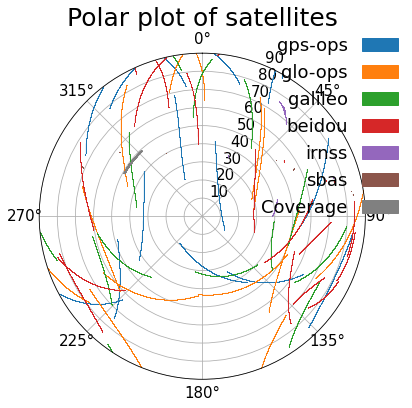

In [58]:
# plotting the trajectory calculations
plot_polar(tsc)


In [15]:
# -------------- plot_under_limit --------------- #
def plot_under_limit(tsc, limit=5, constellation=None):
    ''' Plots satellites that go within the angle limit at least once. '''
    
    # creating figure
    fig, ax = plt.subplots(figsize=(16, 8))
    linestyles = ["-", "--", "-.", ":"]
    dtimes = (tsc.t_start + tsc.times).datetime

    # select satellites under limit at least once and plot
    for i,con in enumerate(tsc.cons):
        if (constellation is not None) and (con!=constellation):  continue
        under_limit = np.any(tsc.angseps[i] < limit, axis=1)
        for j,ID in enumerate(tsc.sats[i].keys()):
            if under_limit[j]:
                angles = tsc.angseps[i][j]
                name = tsc.sats[i][ID].name
                #ax.plot(tsc.times.value, angles, linestyle=next(linestyles), 
                #        label=f"{name}")
                ax.plot(angles, linestyle=linestyles[j%4], 
                        label=f"{name}")

    # showing figure
    ax.axhline(limit, color="black", ls="--")
    #ax.set_xlabel("Time [s]")
    ax.set_ylabel("Angular separation [deg]")
    idx = np.linspace(0, len(dtimes) - 1, 20, dtype=int)
    #ax.set_xticks(tsc.times.value[idx])
    #ax2 = ax.twiny()
    #ax2.set_xlim(ax.get_xlim())
    #ax2.set_xticks(tsc.times.value[idx])
    #ax2.set_xticklabels([t.strftime("%H:%M:%S") for t in dtimes[idx]], rotation=45)
    #ax2.set_xlabel("UTC")
    ax.legend()
    #fig.tight_layout()
    plt.show()
    return


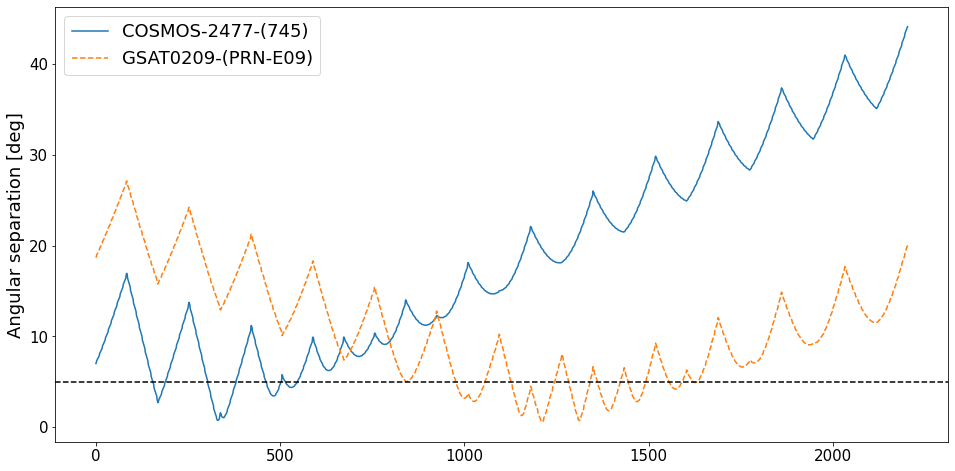

In [60]:
# plotting the satellites under the defined limit
plot_under_limit(tsc, limit=5)


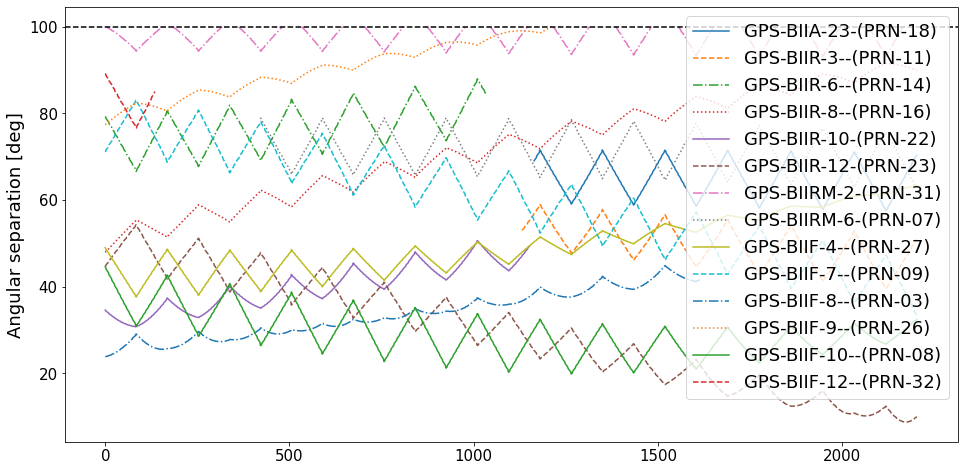

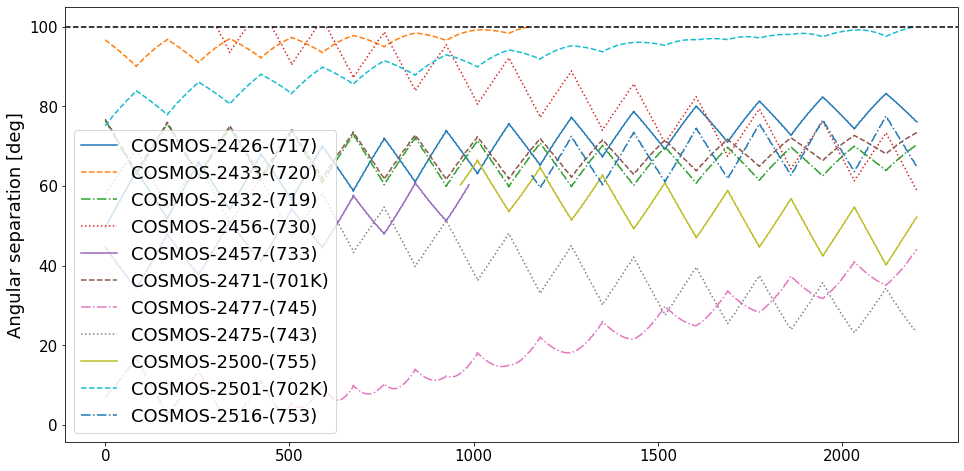

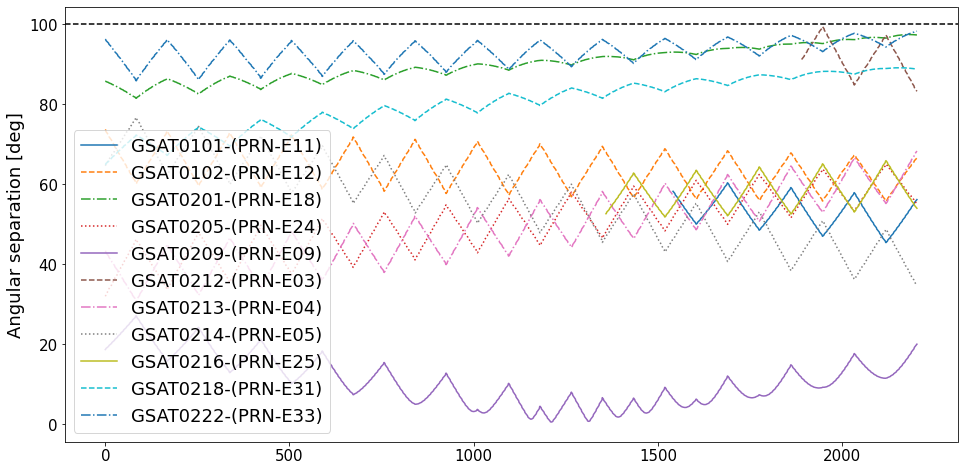

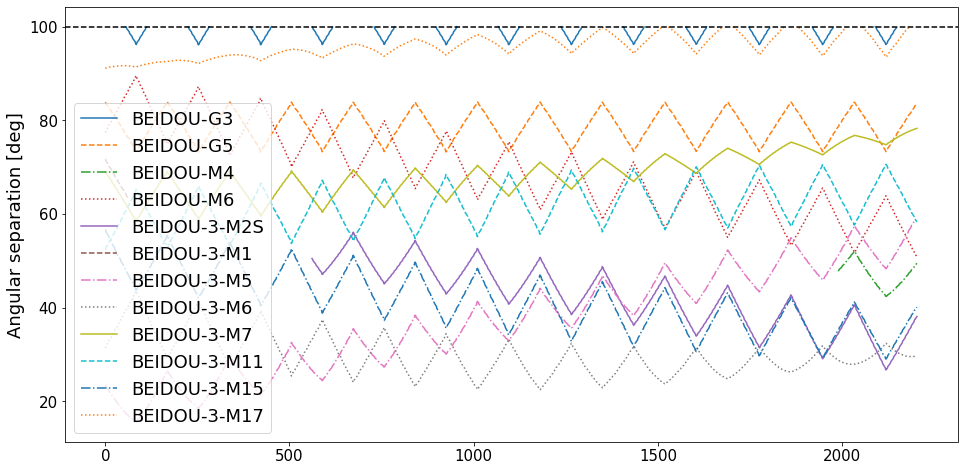

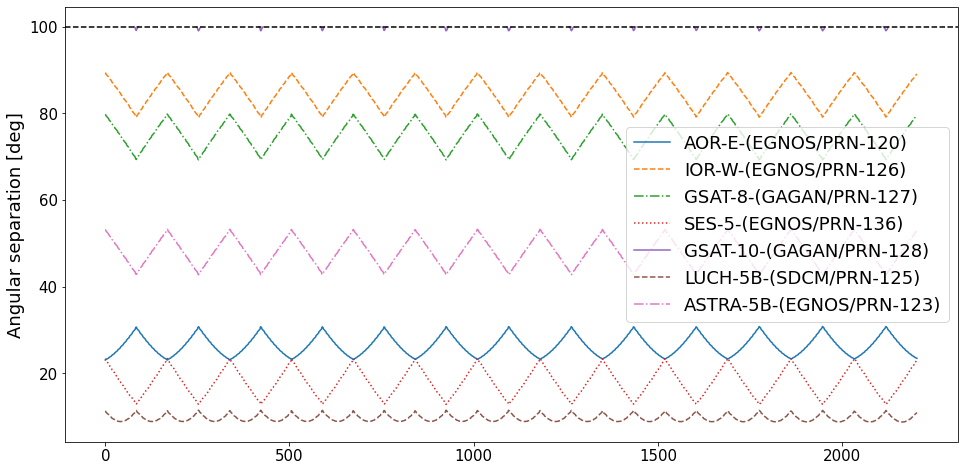

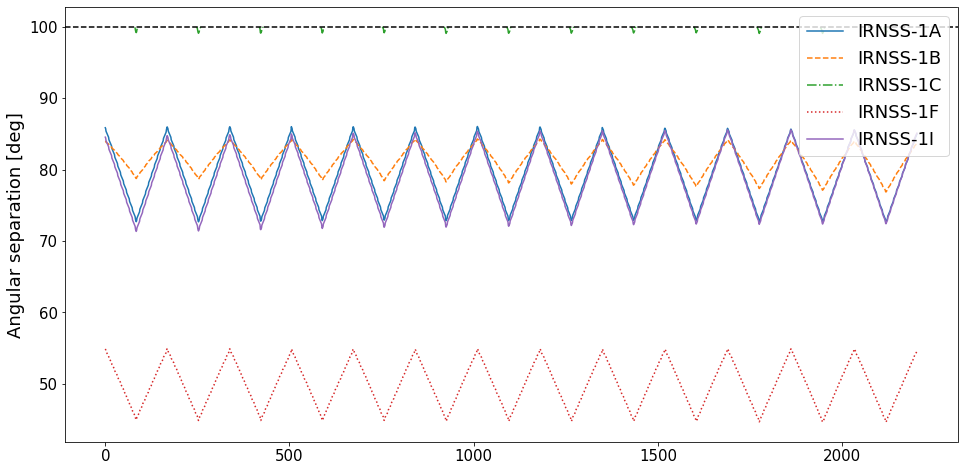

In [61]:
# plotting all satellites
cons = ["gps-ops","glo-ops","galileo","beidou","sbas","irnss"]
for con in cons:
    plot_under_limit(tsc, limit=100, constellation=con)

In [87]:
# --------------- plot_pointings ---------------- #
def plot_pointings(tsc, Ni=None, Nf=None):
    ''' Plot graphs of telescope pointing. '''

    # First figure - creating figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    az = tsc.pointings[Ni:Nf, 0]
    alt = tsc.pointings[Ni:Nf, 1]

    # az,alt plotting
    ax1.plot(tsc.times.value[Ni:Nf], az)
    ax1.set_ylabel("Azimuth [deg]")
    ax2.plot(tsc.times.value[Ni:Nf], alt)
    ax2.set_ylabel("Altitude [deg]")
    ax2.set_xlabel("Time [s]")

    # showing figure
    ax1.ticklabel_format(style="plain", axis="both", useOffset=False)
    ax2.ticklabel_format(style="plain", axis="both", useOffset=False)
    plt.tight_layout()
    plt.show()

    # Second figure - creating figure and plotting
    points = np.column_stack((az, alt)).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="viridis")
    if Nf is None:  lc.set_array(tsc.times.value[Ni:-1])
    else:  lc.set_array(tsc.times.value[Ni:Nf-1])
    lc.set_linewidth(2)

    # showing figure
    fig, ax = plt.subplots()
    ax.add_collection(lc)
    ax.autoscale()
    ax.ticklabel_format(style="plain", axis="both", useOffset=False)
    plt.colorbar(lc, label="Sample index")
    plt.show()
    

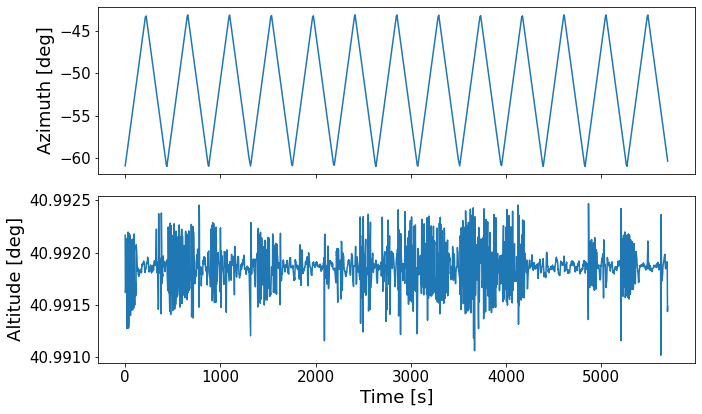

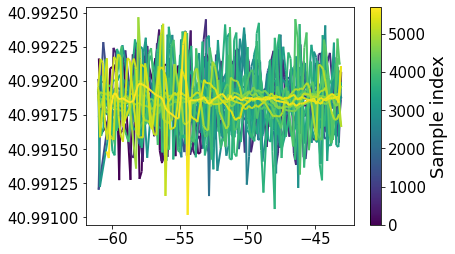

In [86]:
# plotting satellite pointing
plot_pointings(tsc, Ni=None, Nf=None)


In [62]:
# --------- plot_pointings_under_limit ---------- #
def plot_pointings_under_limit(tsc, limit=5):
    """Plot the telescope RA/Dec track, highlighting times 
    when satellites are within 'limit' degrees."""

    # plotting pointings RA,DEC
    RA = pm.nd_s0_coords2[0]
    DEC = pm.nd_s0_coords2[1]
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(RA, DEC, "--", color="k", label="Pointing")

    # replot pointings with satellites within the limit
    for i,con in enumerate(tsc.cons):
        for j,ID in enumerate(tsc.sats[i].keys()):
            angles = tsc.angseps[i][j]
            idx = np.where((angles<limit) & (~angles.mask))[0]
            if len(idx): 
                ax.plot(RA[idx], DEC[idx], ".", label=f"{con}: {tsc.sats[i][ID].name}")

    # showing figure
    ax.set_xlabel("RA [deg]")
    ax.set_ylabel("Dec [deg]")
    ax.legend(frameon=True, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()
    

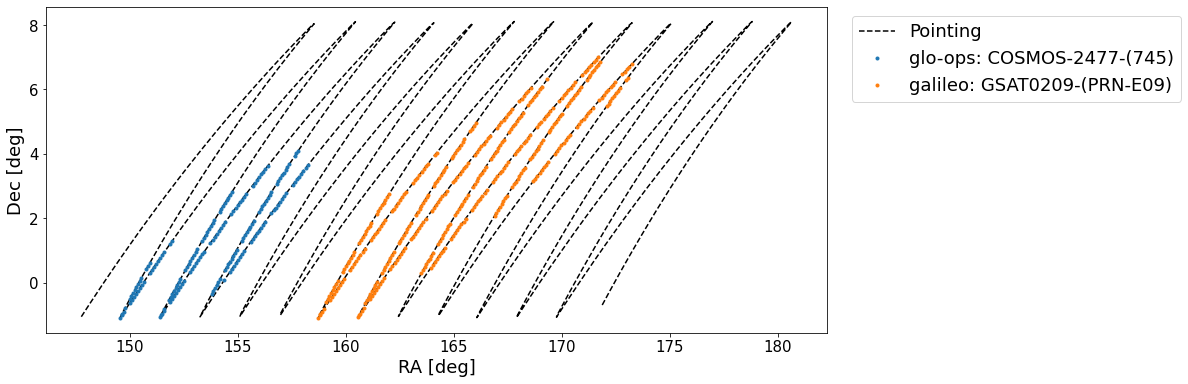

In [63]:
# highlighting pointings with satellites under limit
plot_pointings_under_limit(tsc, limit=5)


#### C. Getting nearby satellites

Created a function in *tle_mapping.py* which checks the satellites that cross below the angle threshold given.

In [6]:
# getting indexes where satellites pass nearby and saving
angles = np.array([1,5])
print(f"Checking angles {angles}...")
data = tsc.get_nearby_sats(angles, verbose=True)
pickle.dump(data,open(pm.path_nearby,'wb'))


Checking angles [1 5]...
Checking angle 1...
	Found satellite COSMOS-2477-(745) (37868) from glo-ops!
	Found satellite GSAT0209-(PRN-E09) (41174) from galileo!
Checking angle 5...
	Found satellite COSMOS-2477-(745) (37868) from glo-ops!
	Found satellite GSAT0209-(PRN-E09) (41174) from galileo!


#### D. Getting satellite telescope beam

We start by defining the necessary functions; as we only have EMSS defined in a specific frequency x theta grid, we interpolate to the desired points using `RectBivariateSpline`.

In [7]:
# getting interpolator
_interp = bm.EMSS_interpolator()
freqs = pm.frequency[(pm.frequency>=pm.freq_range[0]) & (pm.frequency<=pm.freq_range[1])]

# defining beam model
def EMSS(frequency,theta):
    ''' Final EMSS beam with frequency pre-defined. '''
    return bm.EMSS(frequency, theta, _interp)


In [8]:
# calculating satbeam
start = time.perf_counter()
print("Calculating satbeam")
tsc.get_satbeam(freqs,EMSS,verbose=True)
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Calculating satbeam
	Getting gps-ops...
	Getting glo-ops...
	Getting galileo...
	Getting beidou...
	Getting irnss...
	Getting sbas...
This took 191.62 seconds, or 3.19 minutes


In [25]:
# saving data
saved_data = {ID : tsc.satbeam[ID].filled(0) for ID in tsc.satbeam}
pickle.dump(saved_data,open(pm.path_beam,'wb'))


#### E. Checking nearby_sats file

We can see from the plots that the old maps were cutting a lot more indexes than necessary, and that the new values are strictly those where there are satellites below the specified degree. In the end, at the very least this means that the angular mask will take a lesser percentage of the overall data. 

In [9]:
# getting old+new files - nearby
print("Getting old files...")
path_old1 = pm.path_data + f"nearby_satellites/nearby_satellite_close_angle_{'1F'}.p"
old1 = pickle.load(open(path_old1, "rb"), encoding="latin1") 
path_old5 = pm.path_data + f"nearby_satellites/nearby_satellite_close_angle_{'5F'}.p"
old5 = pickle.load(open(path_old5, "rb"), encoding="latin1") 
print("Getting new file...")
new = pickle.load(open(pm.path_nearby, "rb")) 


Getting old files...
Getting new file...


In [10]:
# creating a comparable dictionary
cons = ["gps-ops","glo-ops","beidou","galileo","irnss","sbas"]
lista1 = [];  lista5 = []
for c in cons:
    lista1.append(old1[c])
    lista5.append(old5[c])
old = {}
old[1] = np.unique(np.concatenate(lista1))
old[5] = np.unique(np.concatenate(lista5))


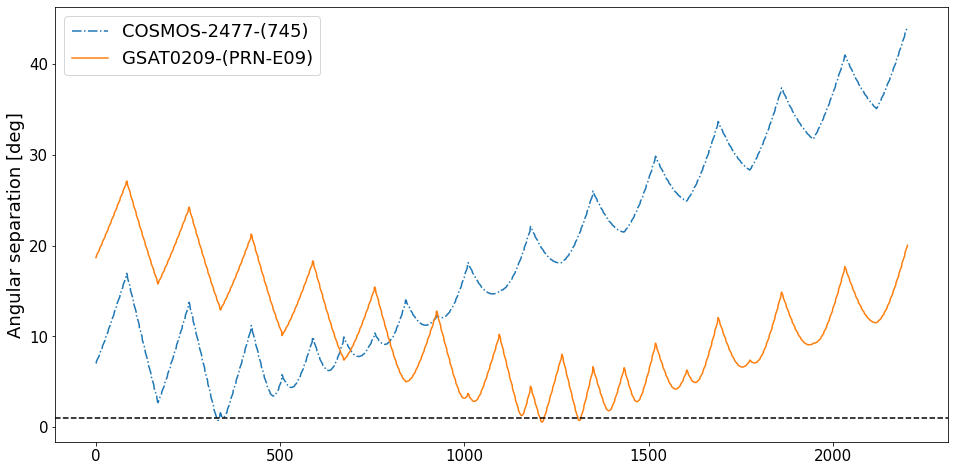

Additional indexes in the old: [1216 1217 1218 1219 1220 1221 1222 1223 1224 1225 1226 1227 1228 1229
 1230 1231 1232 1233 1234 1235 1236 1237 1238 1239 1240 1241 1242 1243
 1244 1245 1246 1247 1248 1249 1250 1251 1252 1253 1254 1255 1256 1257
 1258 1259 1260 1261 1262 1263 1264 1265 1266 1267 1268 1269 1270 1271
 1272 1273 1274 1275 1276 1277 1278 1279 1280 1281 1282 1283 1284 1285
 1286 1287 1288 1289 1290 1291 1292 1293 1294 1295 1296 1297 1298 1299
 1300 1301 1302 1303 1304 1305 1306 1307 1308]
Additional indexes in the new: []


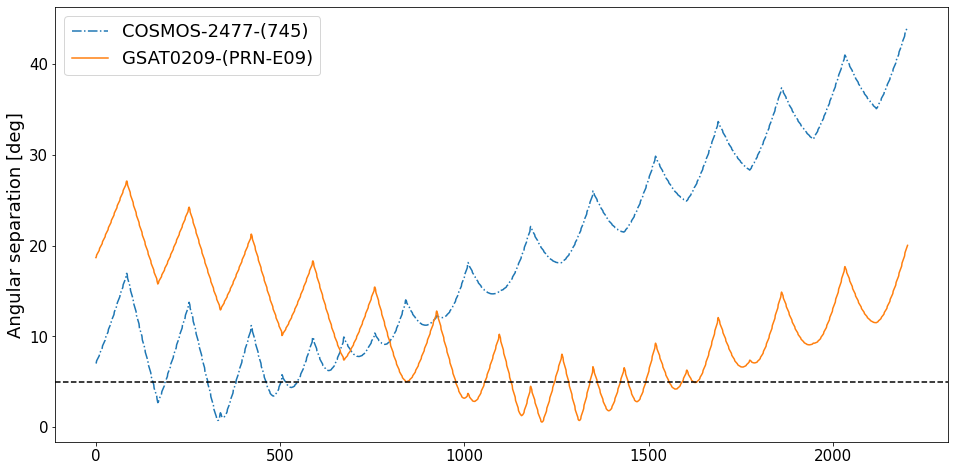

Additional indexes in the old: [ 189  190  191  192  193  194  195  196  197  198  199  200  201  202
  203  204  205  206  207  208  209  210  211  212  213  214  215  216
  217  218  219  220  221  222  223  224  225  226  227  228  229  230
  231  232  233  234  235  236  237  238  239  240  241  242  243  244
  245  246  247  248  249  250  251  252  253  254  255  256  257  258
  259  260  261  262  263  264  265  266  267  268  269  270  271  272
  273  274  275  276  277  278  279  280  281  282  283  284  285  286
  287  288  289  290  291  292  293  294  295  296  297  298  299  300
  301  302  303  381  382  383  384  385  386  387  388  389  390  391
  392  393  394  395  396  397  398  399  400  401  402  403  404  405
  406  407  408  409  410  411  412  413  414  415  416  417  418  419
  420  421  422  423  424  425  426  427  428  429  430  431  432  433
  434  435  436  437  438  439  440  441  442  443  444  445  446  447
  448  449  450  451  452  453  454  455  456 

In [16]:
# checking if the lists are correct
for i in [1,5]:
    plot_under_limit(tsc,i)
    print(f"Additional indexes in the old: {np.setdiff1d(old[i], new[i])}")
    print(f"Additional indexes in the new: {np.setdiff1d(new[i], old[i])}")


#### F. Checking satbeam file

We can also then check if the new files of satbeams are comparable to the old ones or if there are any big discrepancies. Most maps have some differences, that shouldn't be very big in absolute terms but which are comparable to the magnitude of the angular maps themselves. It would be nice to compare if the results are correct or some inconsistencies were written into the code, or if it might just have to do with the EMSS beam - maybe try using the old function to see how they compare? It would be a bit of work.

In [18]:
# getting old values of satbeam
fname = f"simulation_data/satbeamsOLD_{pm.block}_{pm.beam_model}_{pm.freq_range[0]}-{pm.freq_range[1]}.pkl"
data = pickle.load(open(fname,"rb",), encoding="latin1")


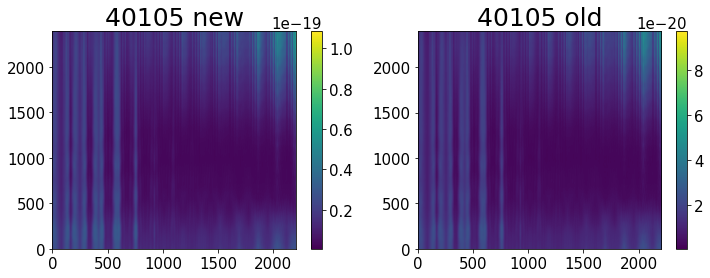

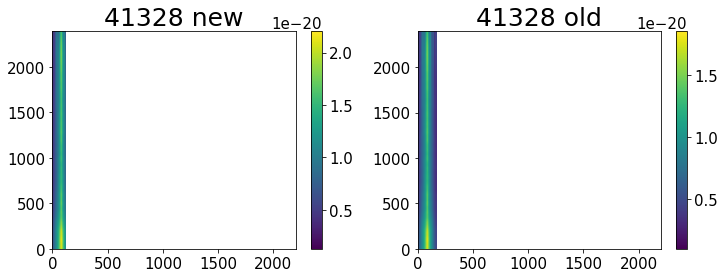

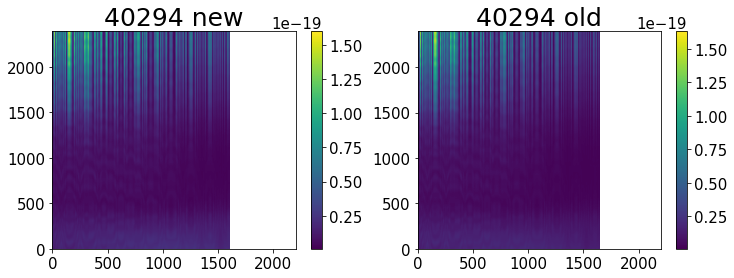

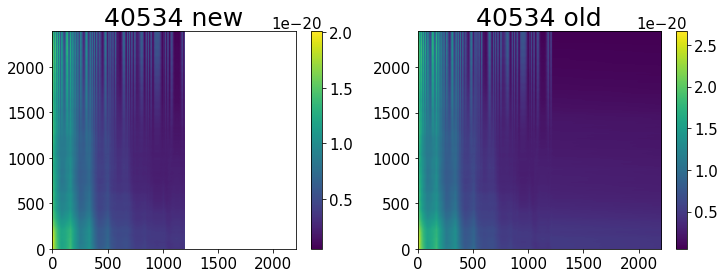

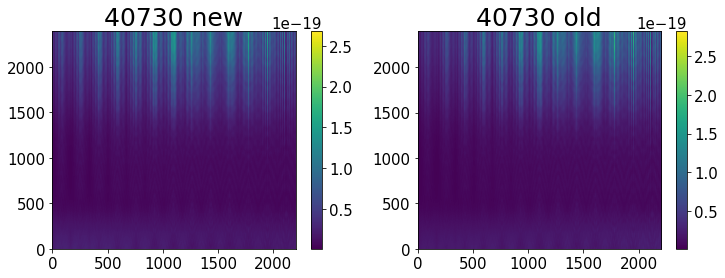

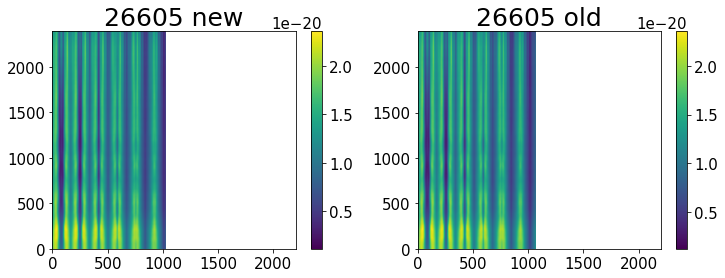

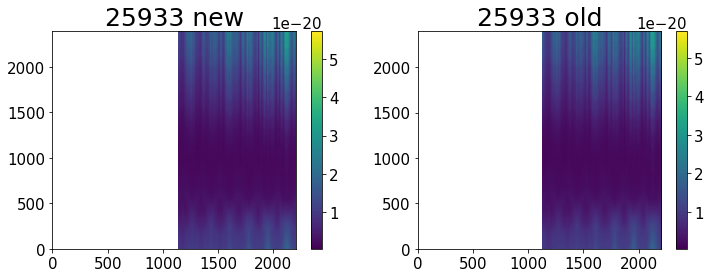

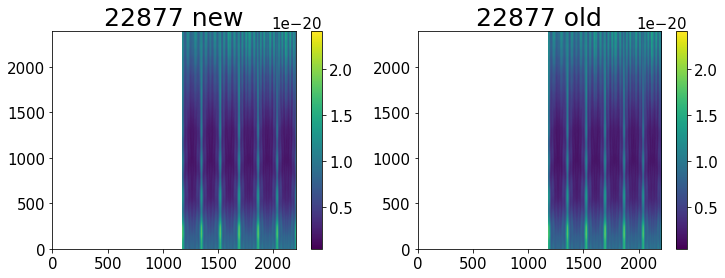

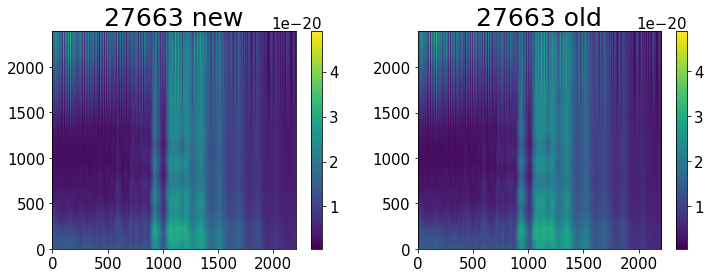

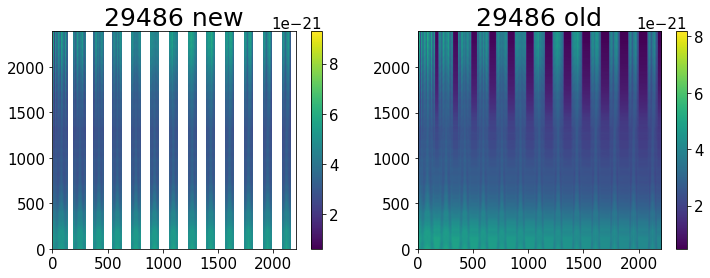

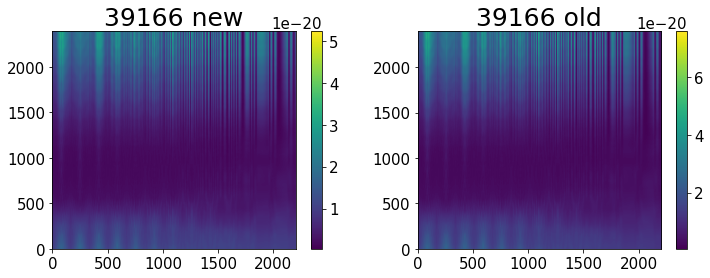

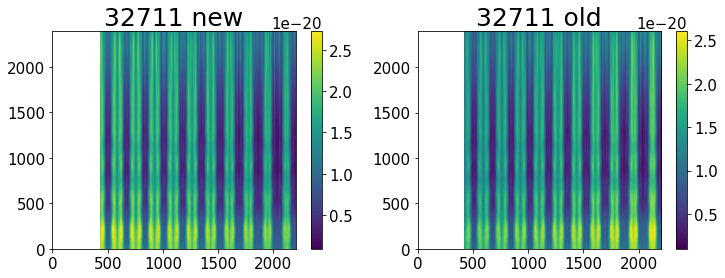

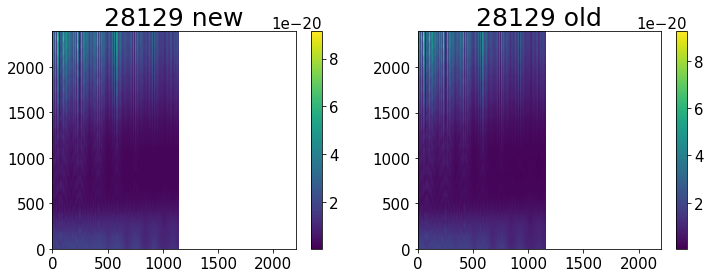

27704 was removed in the new data.


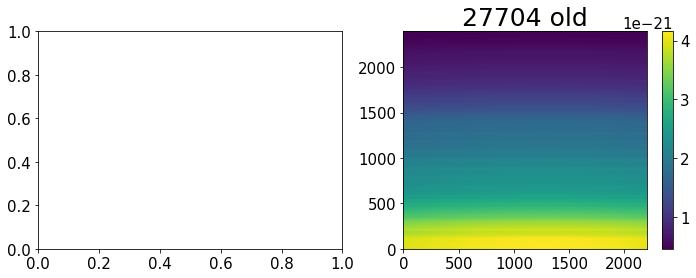

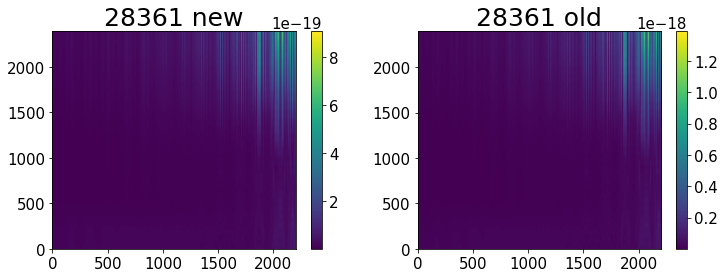

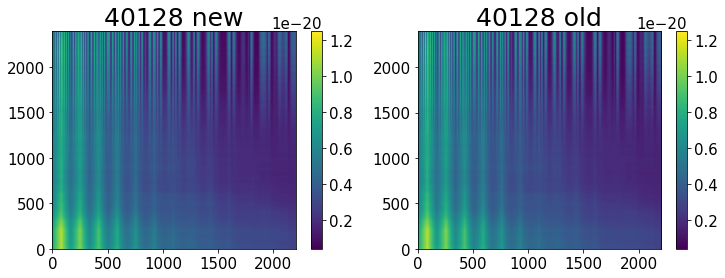

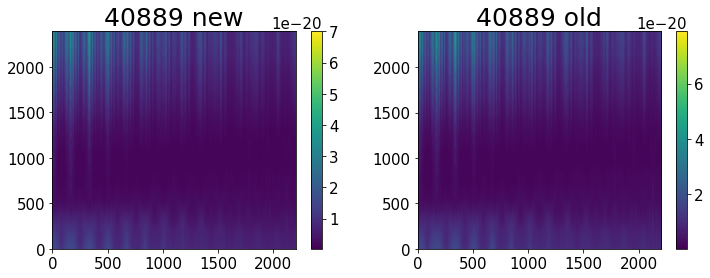

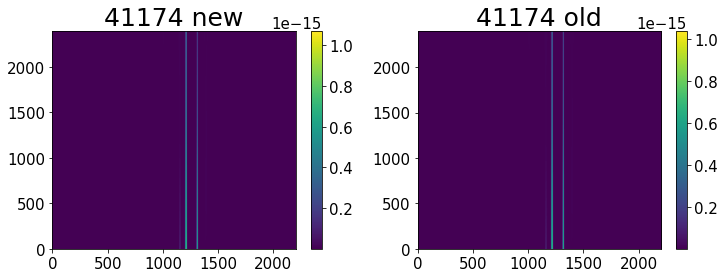

41550 was removed in the new data.


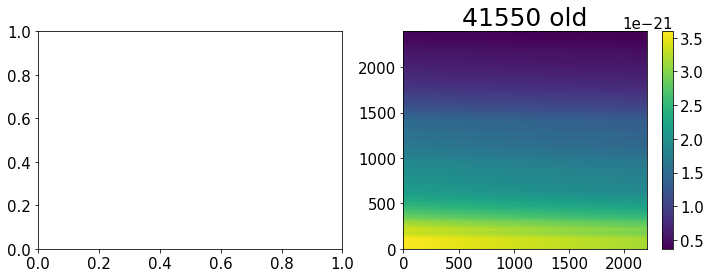

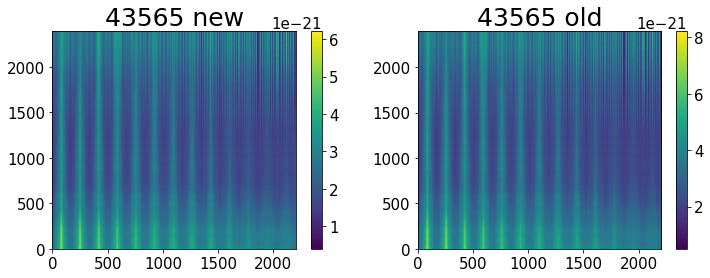

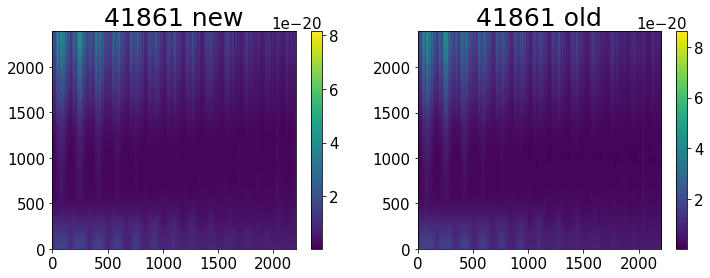

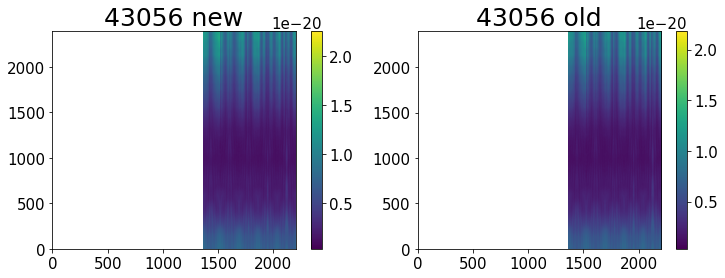

40544 was removed in the new data.


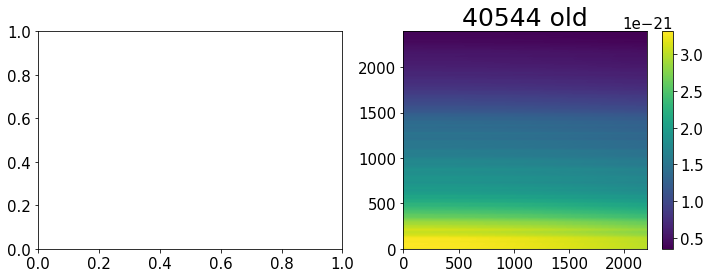

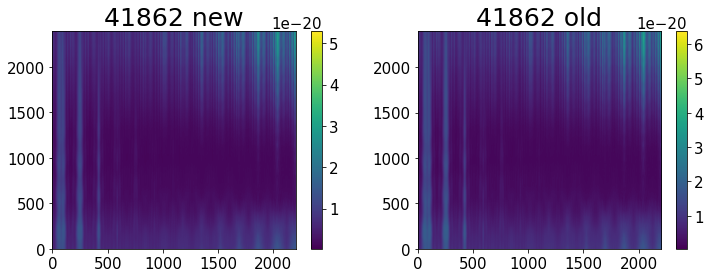

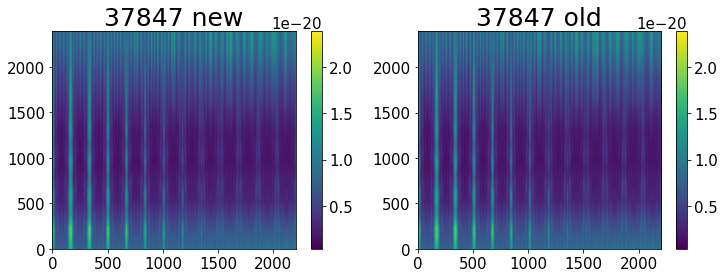

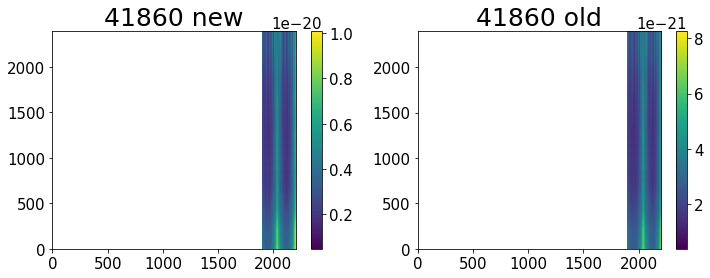

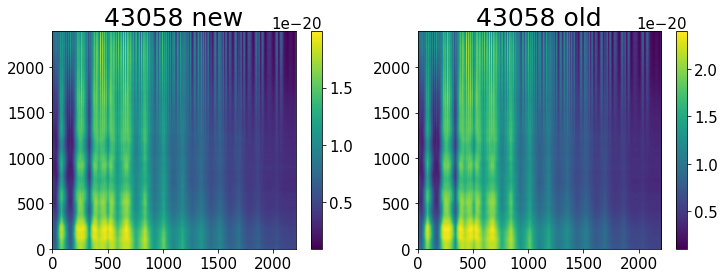

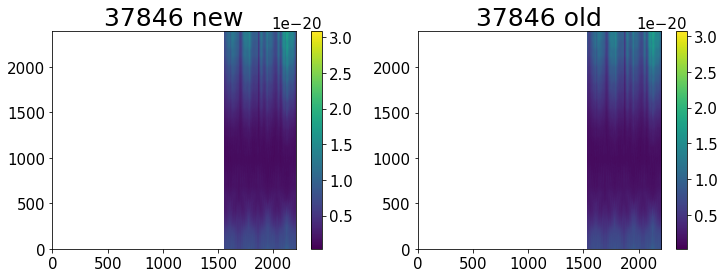

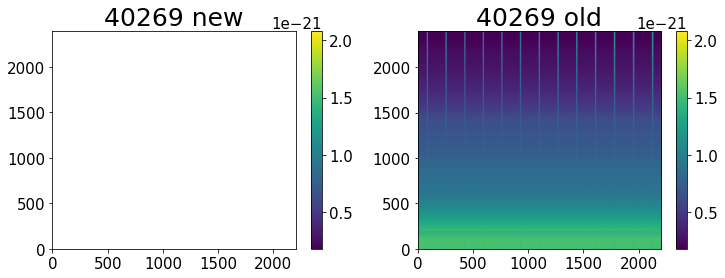

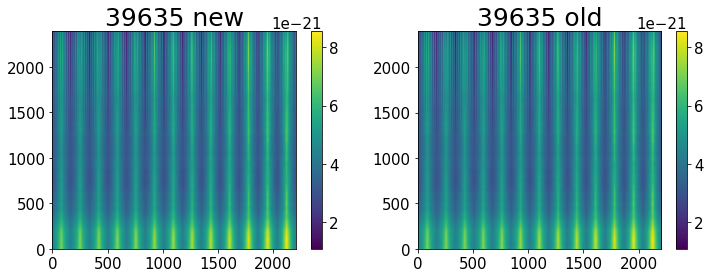

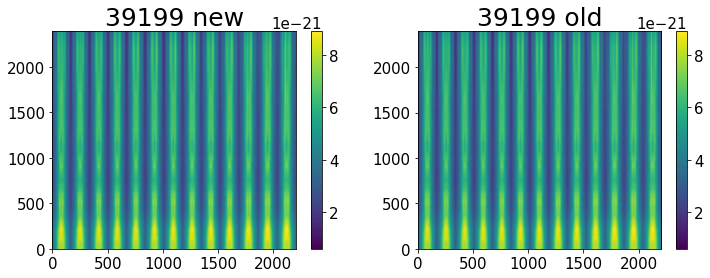

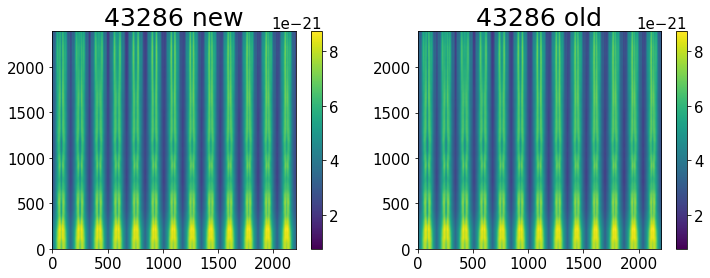

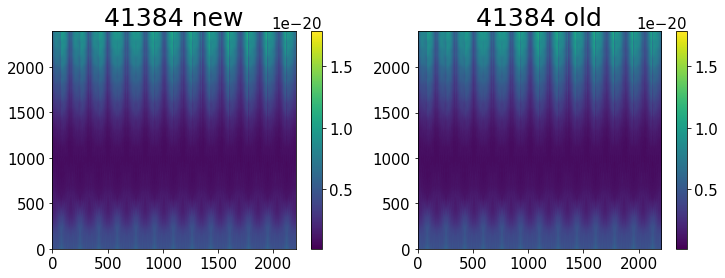

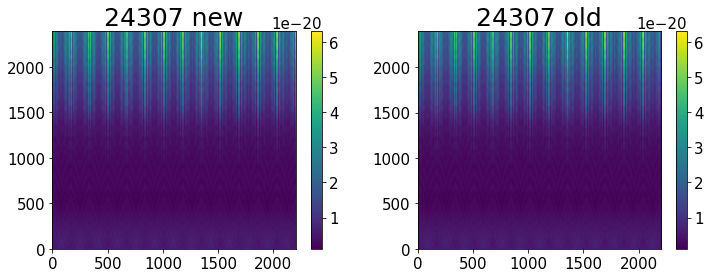

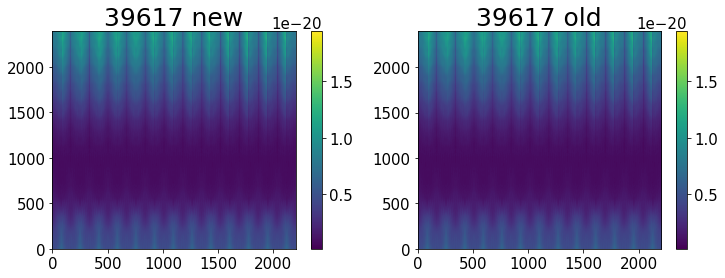

41028 was removed in the new data.


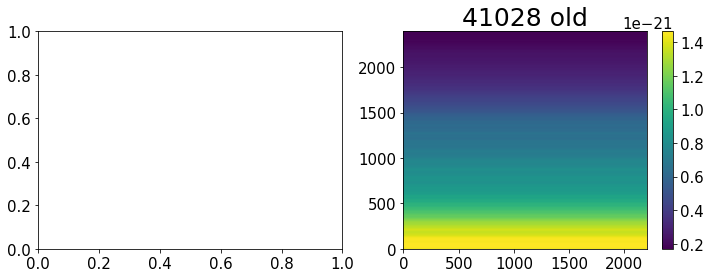

39727 was removed in the new data.


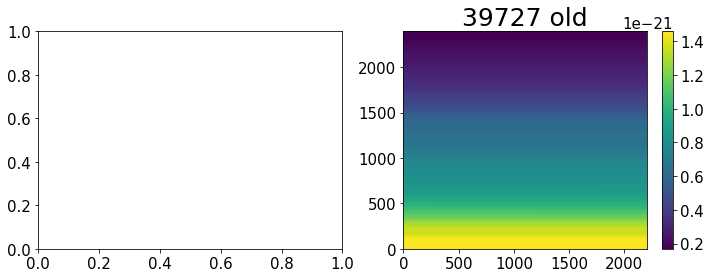

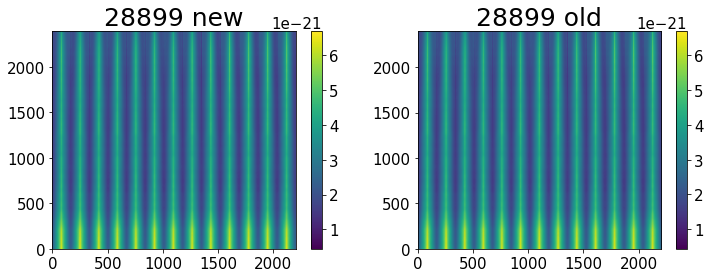

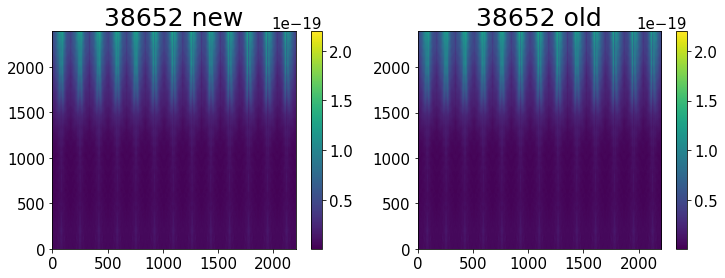

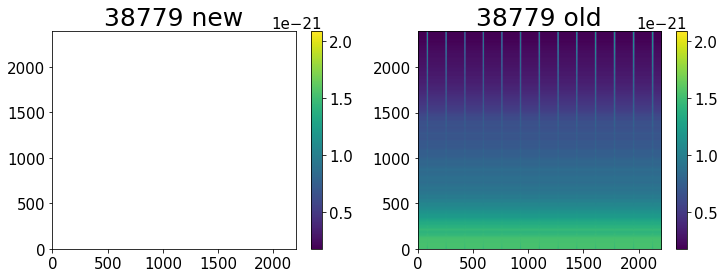

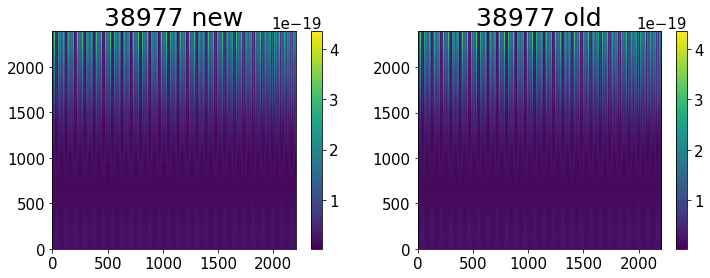

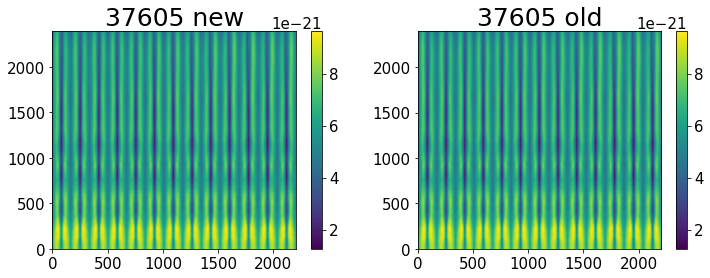

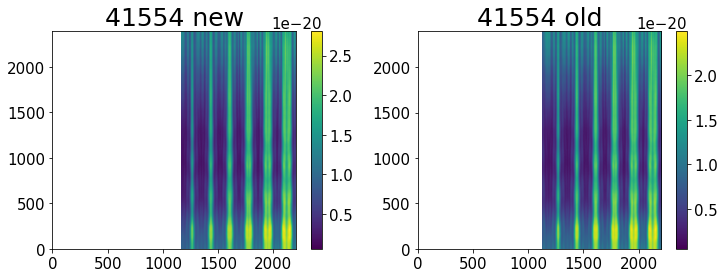

39620 was removed in the new data.


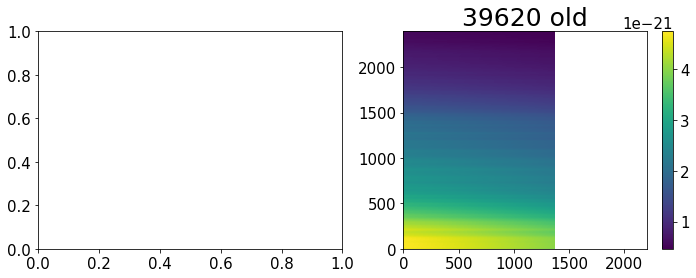

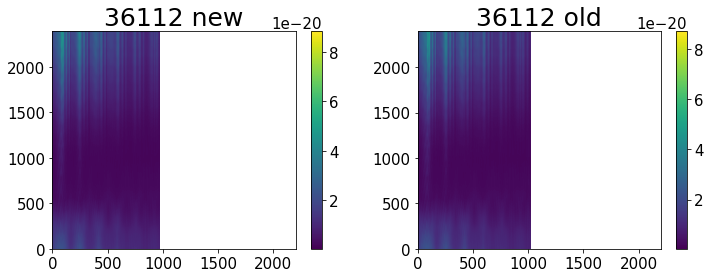

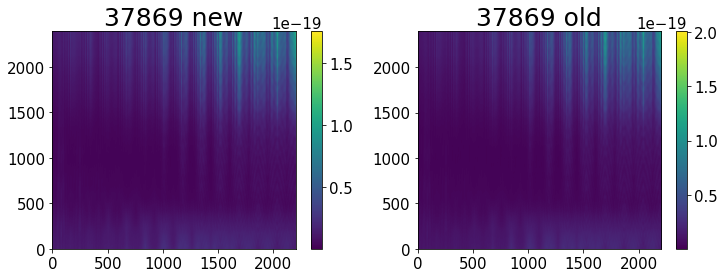

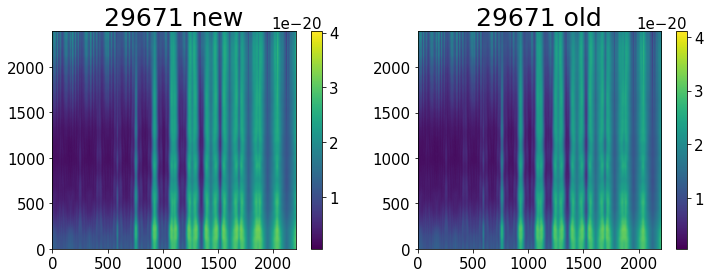

37139 was removed in the new data.


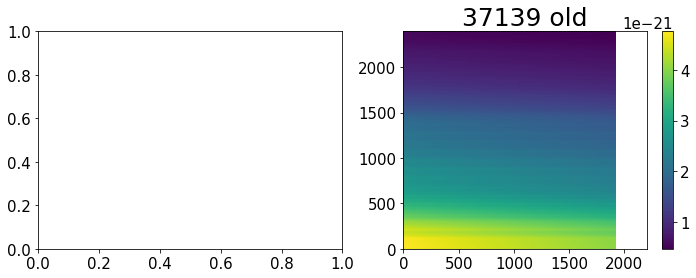

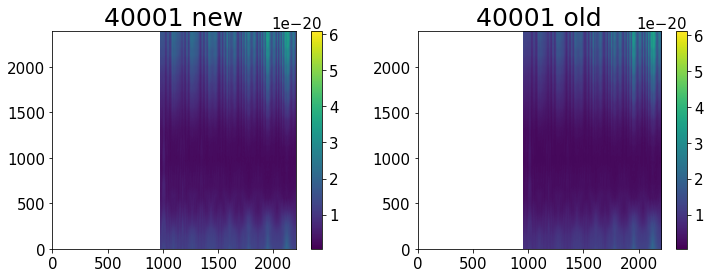

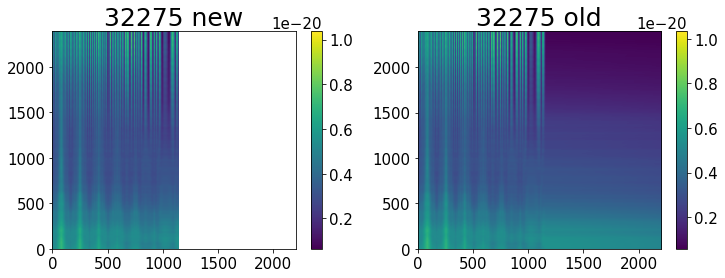

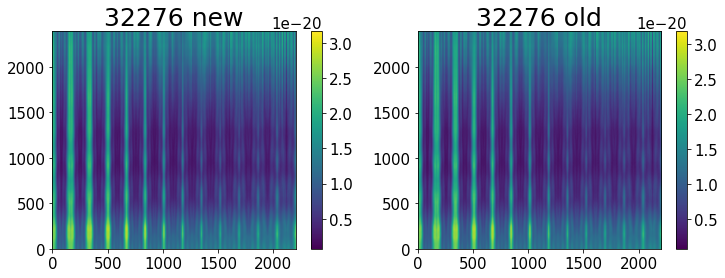

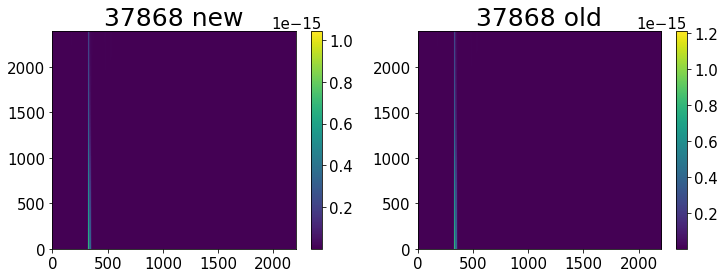

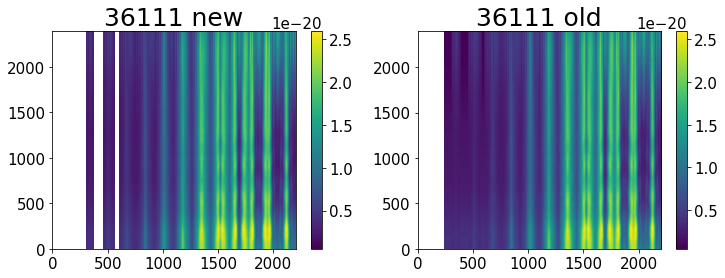

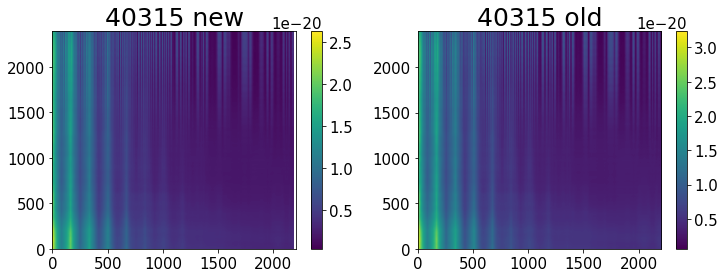

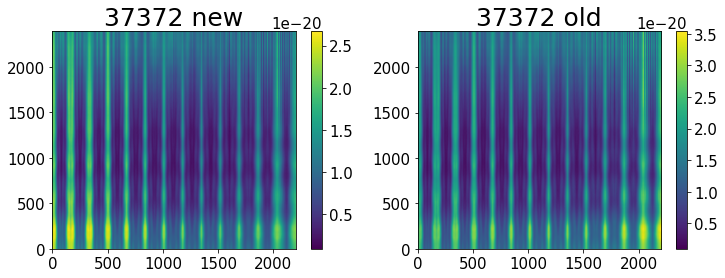

40549 was removed in the new data.


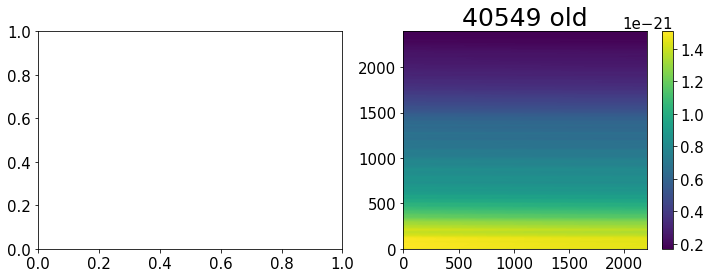

41434 was removed in the new data.


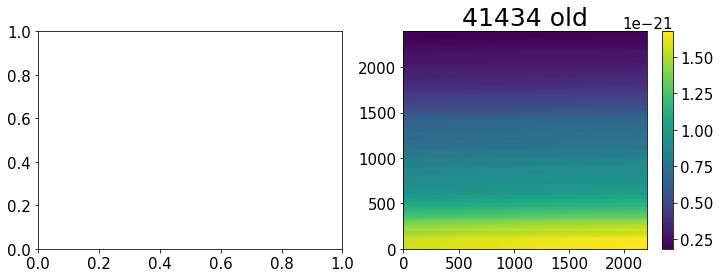

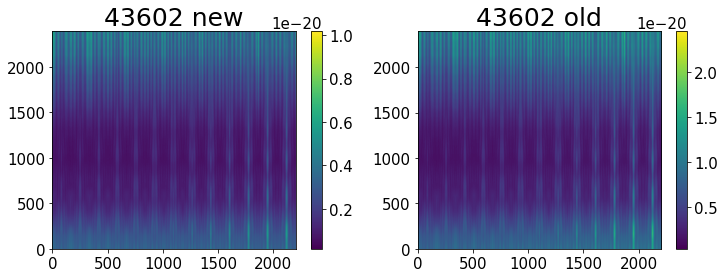

37948 was removed in the new data.


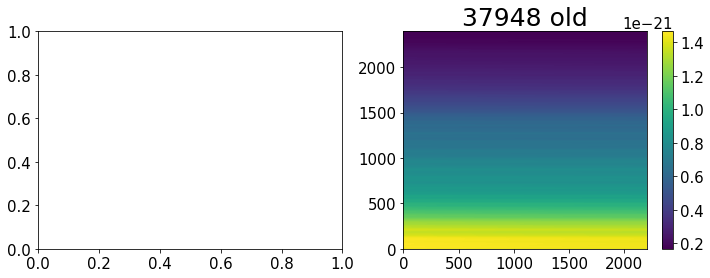

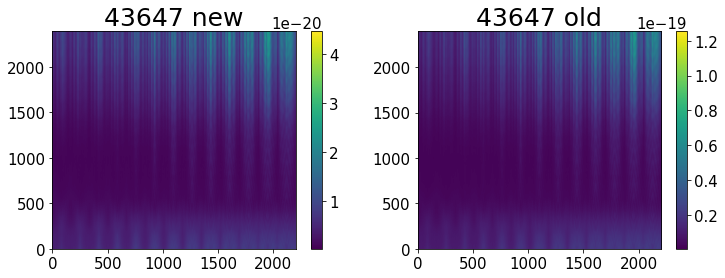

40938 was removed in the new data.


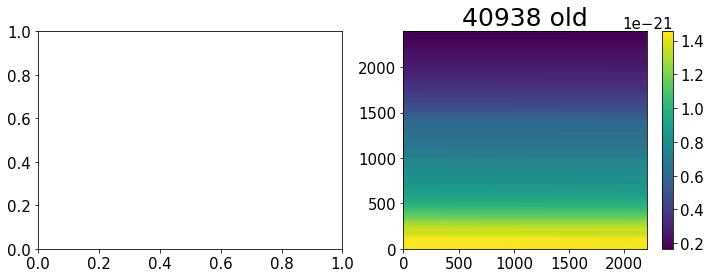

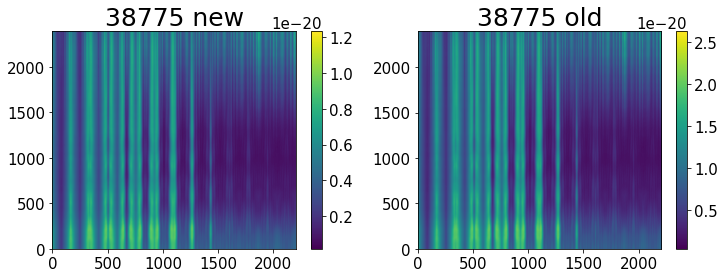

37384 was removed in the new data.


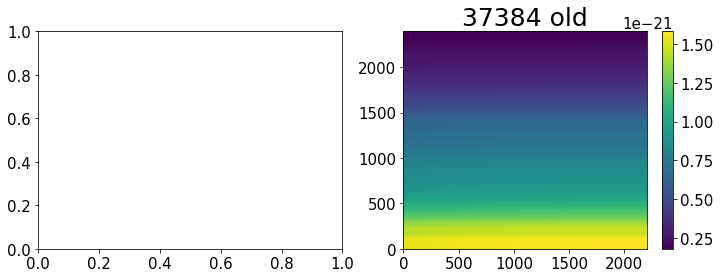

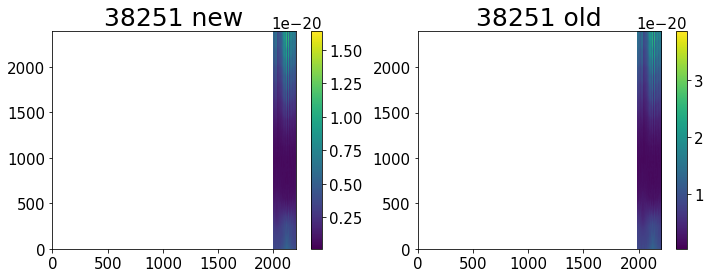

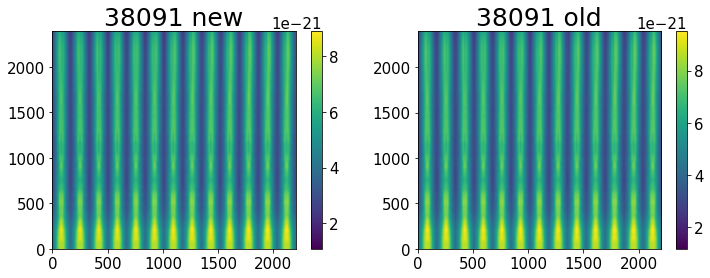

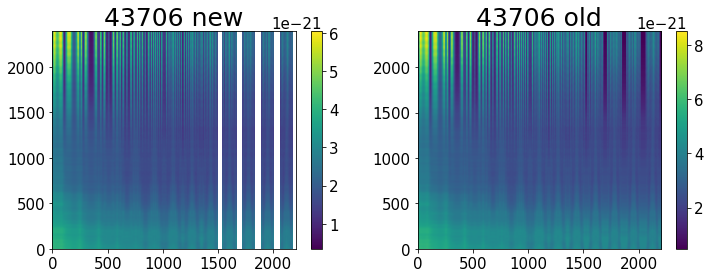

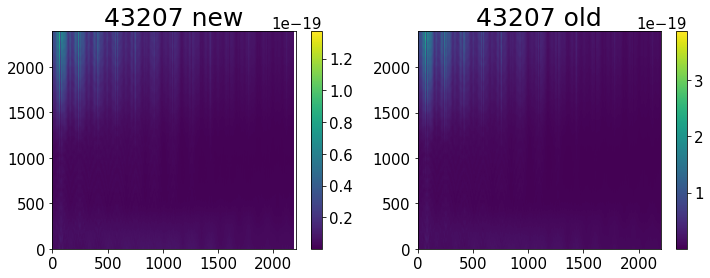

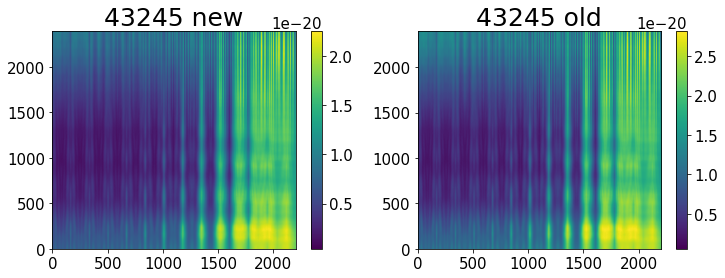

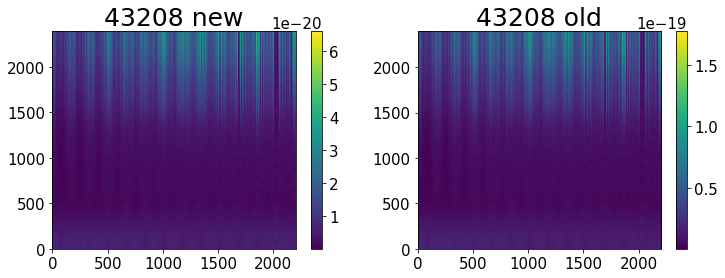

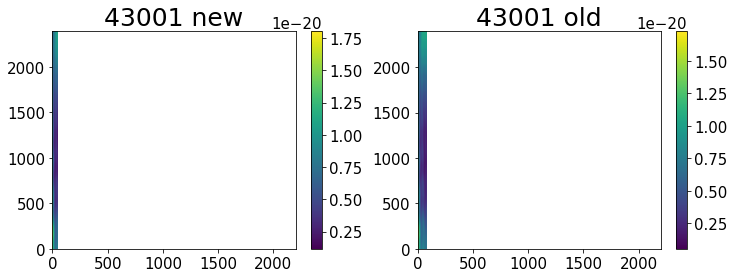

38953 was removed in the new data.


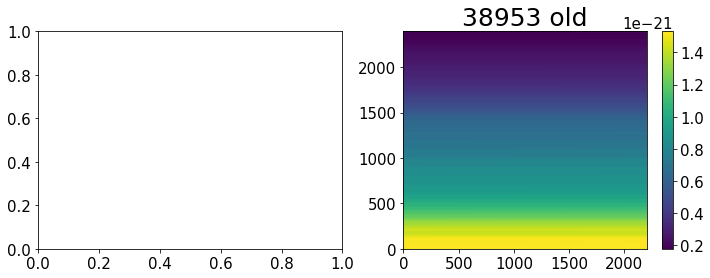

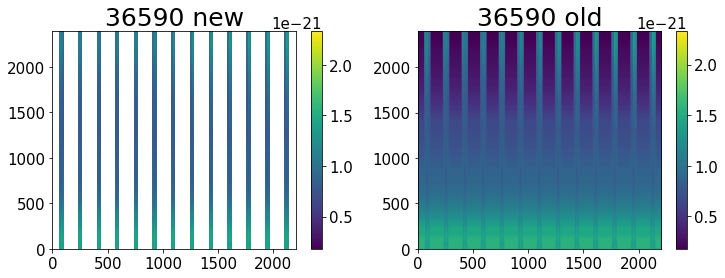

43246 was removed in the new data.


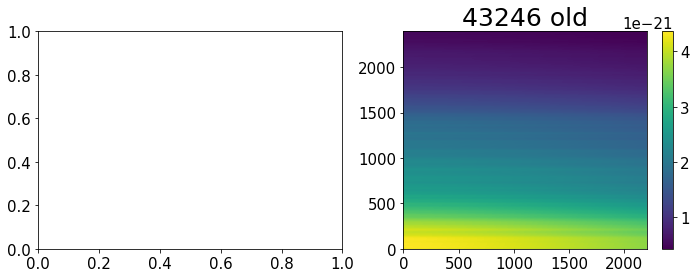

In [29]:
for ID in data:
    
    # Left: old map
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    if ID in tsc.satbeam:
        im1 = ax1.imshow(tsc.satbeam[ID], origin="lower",aspect="auto")
        ax1.set_title(f"{ID} new")
        cbar = fig.colorbar(im1, ax=ax1)
    else: 
        print(f"{ID} was removed in the new data.")
    
    # Right: new map
    im2 = ax2.imshow(np.ma.masked_equal(data[ID],0), origin="lower",aspect="auto")
    ax2.set_title(f"{ID} old")
    cbar = fig.colorbar(im2, ax=ax2)
    plt.show()

    # extra: sat angpos
    plt.plot(tsc.)
    

#### G. Plotting EMSS beam

We can finally check that we retrieve the same satellite beam. They seem to be identical to the images in the article.

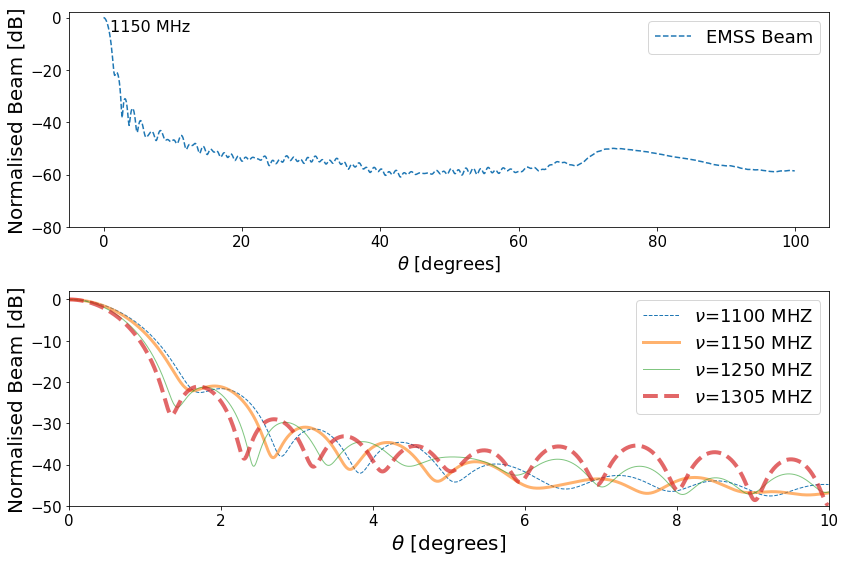

In [42]:
# first plot - all theta
fig, axs = plt.subplots(figsize=(12, 8), nrows=2, ncols=1, sharex=False)
angles1 = np.arange(0, 100, 0.1)
fidx = np.where(freqs > 1150)[0][0]
ax = axs[0]
ax.plot(angles1, 10*np.log10(EMSS(freqs,angles1))[fidx,:], '--', label='EMSS Beam')
ax.text(1, -5, '1150 MHz', fontsize = 16)
ax.set_xlabel(r'$\theta$ [degrees]')
ax.set_ylabel(r'Normalised Beam [dB]', fontsize=20)
ax.set_ylim(-80, 2)
ax.legend(fontsize=18)

# second plot - several frequencies
angles2 = np.arange(0,10,0.01)
fs = [1100, 1150, 1250, 1305]
al = [1, 0.6, 0.6, 0.7]
lw = [1, 3, 1, 4]
ls = ['--', '-', '-', '--']
ax = axs[1]
for fi,fval in enumerate(fs):
    fidx = np.where(freqs>fval)[0][0]
    ax.plot(angles2, 10*np.log10(EMSS(freqs,angles2)[fidx,:]),
        linestyle=ls[fi], alpha=al[fi], linewidth=lw[fi], label = r'$\nu$={} MHZ'.format(fval))

ax.set_xlabel(r'$\theta$ [degrees]', fontsize=20)
ax.set_ylabel(r'Normalised Beam [dB]', fontsize=20)
ax.set_ylim(-50, 2)
ax.set_xlim(0, 10)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()